In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [2]:
# import rasterio
# import matplotlib.pyplot as plt
# import torch

# # مسار الصورة والماسک

# images=[]
# masks=[]
# Training_data = []
# Validation_data = []
# Testing_data = []
# # قراءة الصورة grayscale
# with rasterio.open(image_path) as src:
#     image = src.read(range(1, 13))  #(R,G,B,NIR,SWIR1,SWIR2, etc.)
#     images.append(image)



# # with rasterio.open(mask_path) as src:
# #     mask = src.read(1)
# #     masks.append(mask)

# # # تحويل للصورة والماسک إلى torch tensors (اختياري للتدريب)
# # image_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0)  # 1xHxW
# # # mask_tensor  = torch.tensor(mask, dtype=torch.long)                    # HxW

# # # عرض الصورة + الماسك
# fig, axs = plt.subplots(1, 2, figsize=(10,5))
# image = image.transpose(1,2,0)  # (3,H,W) → (H,W,3)
# # axs[0].imshow(image)
# axs[0].set_title("RGB Image")
# axs[0].axis('off')

# # axs[1].imshow(mask, cmap='gray')
# # axs[1].set_title("Binary Mask")
# # axs[1].axis('off')

# plt.show()

In [ ]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt


    # coastal= img[0].astype(np.float32)    # Index 0 for coastal 
    # blue = img[1].astype(np.float32)  # Index 2 for blue (0-based indexing)
    # green = img[2].astype(np.float32)   # Index 1 for green
    # red   = img[3].astype(np.float32)   # Index 3 for red
    # nir   = img[4].astype(np.float32)   # Index 4 for NIR
    # swir1 = img[5].astype(np.float32)  # Index 5 for SWIR1
    # swir2 = img[6].astype(np.float32)  # Index 6 for SWIR2
 
def load_image_mask(image_path, mask_path=None):
    with rasterio.open(image_path) as src:
        img = src.read(range(1, 13))
        img = np.transpose(img, (1, 2, 0)).astype(np.float32)
        img = img / 255.0

        # Extract key bands
        red = img[:, :, 3]     # Band 4: Red
        green = img[:, :, 2]    # Band 3: Green
        blue = img[:, :, 1]     # Band 2: Blue
        nir = img[:, :, 4]      # Band 5: NIR
        swir2=img[:,:,6]         #band 7: SWIR2
        
        # Calculate NDWI
        ndwi = (green - swir2) / (swir2 + green + 1e-6)
        ndwi = np.expand_dims(ndwi, axis=-1)
        
        # Stack RGB + NDWI (4 channels)
        img = np.stack([red, green, blue, ndwi[:, :, 0]], axis=-1)

    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.float32)
        # mask = mask / 255.0 if mask.max() > 1 else mask
    
    fig, axs = plt.subplots(1, 2, figsize=(10,5))
    im = axs[0].imshow(ndwi)
    plt.colorbar(im, ax=axs[0], label='NDWI')
    axs[0].set_title("NDWI - Water Index")
    axs[0].axis('off')
    im=axs[1].imshow(mask,cmap="gray")
    axs[1].set_title("Mask - Water Index")
    axs[1].axis('off')
    plt.colorbar(im, ax=axs[1], label='Mask')
    plt.tight_layout()
    plt.show()

    return img, mask

In [4]:
def readImage(image_path , mask_path):
    with rasterio.open(image_path) as src:
        img = src.read(range(1, 13))
        img = np.transpose(img, (1,2,0))
        img=img/255.0
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
        print(mask)
        return(img,mask)

In [7]:
image_dir = "Satellitedata/data/images"
mask_dir  = "Satellitedata/data/labels"

images=[os.path.join(image_dir, file) for file in os.listdir(image_dir)]
i=0
masks=[]
for file in os.listdir(mask_dir):
    if "_" in file:
        continue
    masks.append(os.path.join(mask_dir, file))

finalImages=[]
finalMasks=[]
for i in range(len(images)):
    finalImages.append(load_image_mask(images[i], masks[i])[0])  # Append the image part
    finalMasks.append(load_image_mask(images[i], masks[i])[1])   # Append the mask part

In [8]:
import tensorflow as tf
import numpy as np

def augment_image_mask(image, mask):
    # 1. Flip horizontally
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask  = tf.image.flip_left_right(mask)
    
    # 2. Flip vertically
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask  = tf.image.flip_up_down(mask)
    
    # 3. Random rotation 0, 90, 180, 270
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask  = tf.image.rot90(mask, k)

    image = tf.image.random_brightness(image, max_delta=0.05)
    # Ensure values stay in valid range
    image = tf.clip_by_value(image, 0.0, 1.0)
    
    return image, mask



In [9]:

finalImages = np.array(finalImages, dtype=np.float32)
finalMasks  = np.array(finalMasks, dtype=np.float32)
finalMasks  = np.expand_dims(finalMasks, axis=-1) # Add channel dimension to masks
print(finalImages.shape)
dataset = tf.data.Dataset.from_tensor_slices((finalImages, finalMasks))
train_size = int(0.6 * len(dataset))  
valid_size= int(0.2 * len(dataset))  
train_dataset = dataset.take(train_size) #183
val_dataset   = dataset.skip(train_size).take(valid_size) 
test_dataset   = dataset.skip(train_size+valid_size)
# print(len(train_dataset))
# print(len(val_dataset))
train_dataset = (train_dataset
                 .map(augment_image_mask)
                 .batch(8) 
                 .prefetch(tf.data.AUTOTUNE))

val_dataset = (val_dataset
               .batch(8)
               .prefetch(tf.data.AUTOTUNE))

test_dataset=(test_dataset
              .batch(8)
              .prefetch(tf.data.AUTOTUNE))


(306, 128, 128, 4)


In [43]:
# def unet_model(input_shape=(128, 128, 4)):
    # """U-Net with proper input shape for 13 bands"""
inputs = keras.Input(shape=(128, 128, 3))  # 4 channels: R, G, B, NDWI

# Encoder
conv1 = keras.layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
conv1 = keras.layers.Conv2D(64, 3, activation='relu', padding='same')(conv1)
pool1 = keras.layers.MaxPooling2D(2)(conv1)

conv2 = keras.layers.Conv2D(128, 3, activation='relu', padding='same')(pool1)
conv2 = keras.layers.Conv2D(128, 3, activation='relu', padding='same')(conv2)
pool2 = keras.layers.MaxPooling2D(2)(conv2)

conv3 = keras.layers.Conv2D(256, 3, activation='relu', padding='same')(pool2)
conv3 = keras.layers.Conv2D(256, 3, activation='relu', padding='same')(conv3)
pool3 = keras.layers.MaxPooling2D(2)(conv3)

conv4 = keras.layers.Conv2D(512, 3, activation='relu', padding='same')(pool3)
conv4 = keras.layers.Conv2D(512, 3, activation='relu', padding='same')(conv4)
drop4 = keras.layers.Dropout(0.3)(conv4)
pool4 = keras.layers.MaxPooling2D(2)(drop4)

# Bridge
conv5 = keras.layers.Conv2D(1024, 3, activation='relu', padding='same')(pool4)
conv5 = keras.layers.Conv2D(1024, 3, activation='relu', padding='same')(conv5)
drop5 = keras.layers.Dropout(0.3)(conv5)

# Decoder
up6 = keras.layers.Conv2DTranspose(512, 2, strides=2, padding='same')(drop5)
concat6 = keras.layers.concatenate([up6, drop4])
conv6 = keras.layers.Conv2D(512, 3, activation='relu', padding='same')(concat6)
conv6 = keras.layers.Conv2D(512, 3, activation='relu', padding='same')(conv6)

up7 = keras.layers.Conv2DTranspose(256, 2, strides=2, padding='same')(conv6)
concat7 = keras.layers.concatenate([up7, conv3])
conv7 = keras.layers.Conv2D(256, 3, activation='relu', padding='same')(concat7)
conv7 = keras.layers.Conv2D(256, 3, activation='relu', padding='same')(conv7)

up8 = keras.layers.Conv2DTranspose(128, 2, strides=2, padding='same')(conv7)
concat8 = keras.layers.concatenate([up8, conv2])
conv8 = keras.layers.Conv2D(128, 3, activation='relu', padding='same')(concat8)
conv8 = keras.layers.Conv2D(128, 3, activation='relu', padding='same')(conv8)

up9 = keras.layers.Conv2DTranspose(64, 2, strides=2, padding='same')(conv8)
concat9 = keras.layers.concatenate([up9, conv1])
conv9 = keras.layers.Conv2D(64, 3, activation='relu', padding='same')(concat9)
conv9 = keras.layers.Conv2D(64, 3, activation='relu', padding='same')(conv9)

outputs = keras.layers.Conv2D(1, 1, activation='sigmoid')(conv9)

model = keras.Model(inputs=inputs, outputs=outputs)
    # return model

c:\Users\HUAWEI\AppData\Local\Programs\Python\Python311\Lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


(1, 128, 128, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step


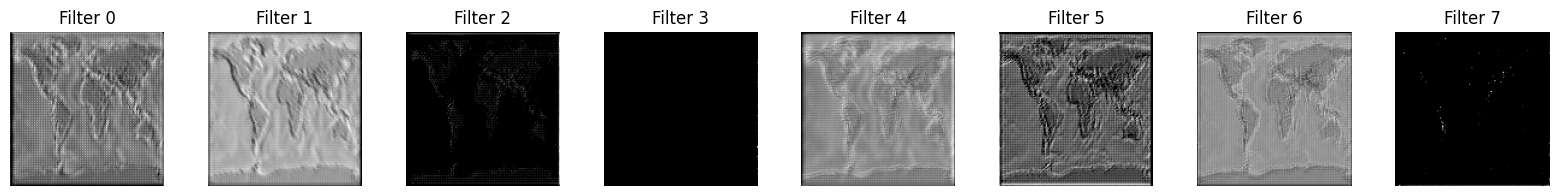

In [ ]:
# model = unet_model()
# model.summary()
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Create a sub-model that stops at this layer
visual_model = tf.keras.Model(inputs=inputs, outputs=conv9)  # Change 'pool1' to the layer you want to visualize

# 2. Get the output for one image
# Assuming 'sample_img' is your input (1, height, width, channels)
image="c0386873-800px-wm.jpg"
with rasterio.open(image) as src:
    img = src.read()
    img = np.transpose(img, (1, 2, 0)).astype(np.float32)
    img_resized = tf.image.resize(img, (128, 128)) # removes the extra '1' dimension first
    img_final = np.expand_dims(img_resized, axis=0)   # adds the batch dimension back: (1, 128, 128, 3)
    print(img_final.shape)
feature_maps = visual_model.predict(img_final)  # Get feature maps for the first image

# 3. Plot the first 8 filters to see their specific outputs
fig, axes = plt.subplots(1, 8, figsize=(20, 2))
for i in range(8):
    axes[i].imshow(feature_maps[0, :, :, i], cmap='gray')
    axes[i].set_title(f"Filter {i}")
    axes[i].axis('off')


In [ ]:
num_classes = 2
def dice_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)

    smooth = 1e-6
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)

    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

model.compile(optimizer='adam', loss="focal_loss", metrics=[tf.keras.metrics.MeanIoU(num_classes=2)])
model.fit(train_dataset, epochs=20, validation_data=val_dataset)

Epoch 1/20


23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - loss: 0.8860 - mean_io_u_6: 0.3621 - val_loss: 1.5968 - val_mean_io_u_6: 0.3834
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 63s 3s/step - loss: 0.8310 - mean_io_u_6: 0.3693 - val_loss: 1.0729 - val_mean_io_u_6: 0.3827
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 160s 7s/step - loss: 0.6929 - mean_io_u_6: 0.3621 - val_loss: 1.4816 - val_mean_io_u_6: 0.3833
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 160s 7s/step - loss: 0.6815 - mean_io_u_6: 0.3621 - val_loss: 1.2117 - val_mean_io_u_6: 0.3832
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 194s 9s/step - loss: 0.6663 - mean_io_u_6: 0.3621 - val_loss: 1.3947 - val_mean_io_u_6: 0.3830
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 356s 16s/step - loss: 0.6714 - mean_io_u_6: 0.3621 - val_loss: 1.3716 - val_mean_io_u_6: 0.3833
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 173s 7s/step - loss: 0.6570 - mean_io_u_6: 0.3621 - val_loss: 1.4857 - val_mean_io_u_6: 0.3832
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 160s 7s/step - loss: 0.6614 - mean_io_u_6: 

In [100]:
eval = model.evaluate(test_dataset)
print(f"test loss : {eval[0]}  , iou_metric : {eval[1]}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 503ms/step - loss: 1.6538 - mean_io_u_6: 0.4172
test loss : 1.6537669897079468  , iou_metric : 0.4171784520149231


In [109]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Function to compute IoU
def iou_score(y_true, y_pred):
    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    if union == 0:
        return 1.0  # perfect if no water in both
    return intersection / union

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step


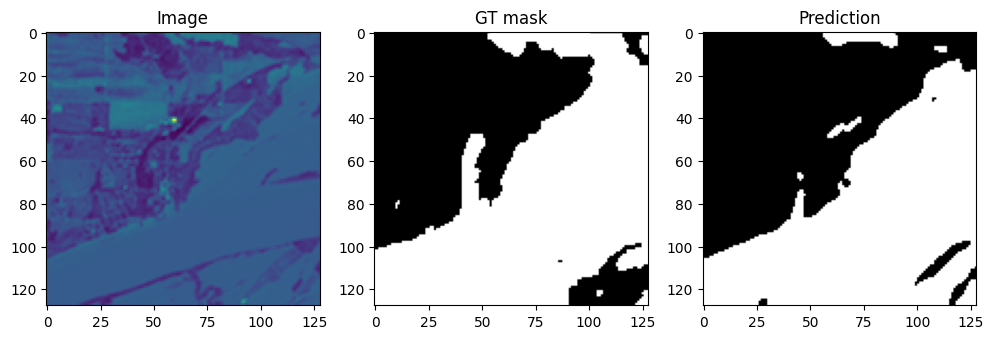

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step


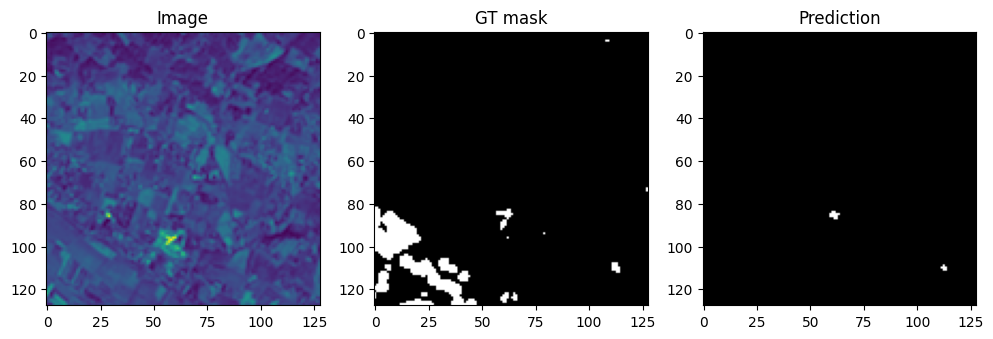

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step


c:\Users\HUAWEI\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HUAWEI\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HUAWEI\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{met

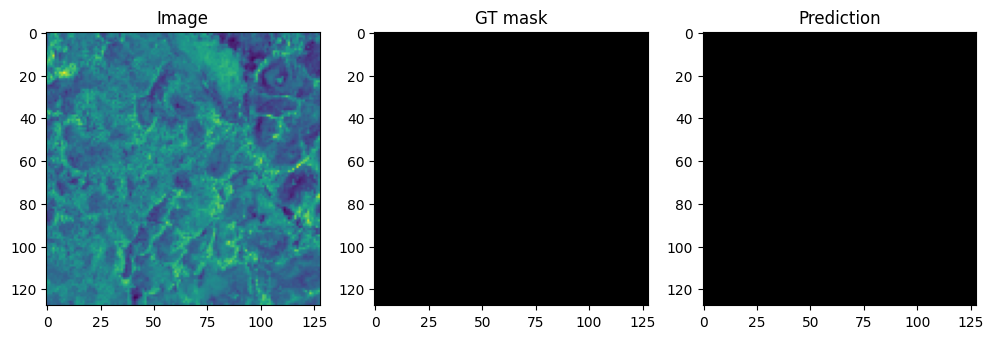

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step


c:\Users\HUAWEI\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


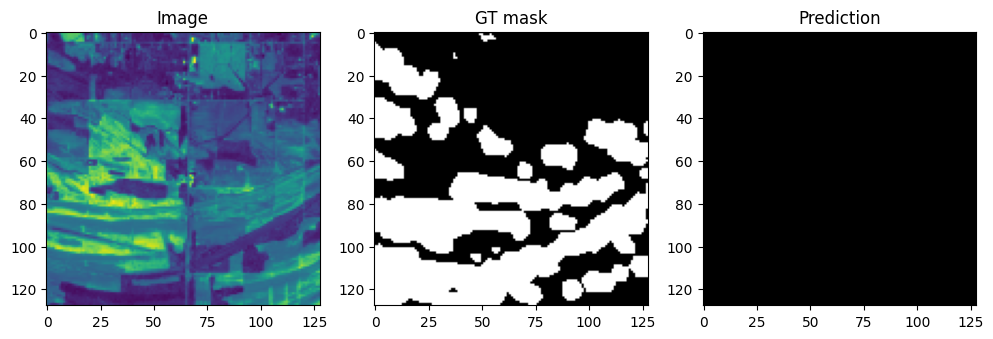

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step


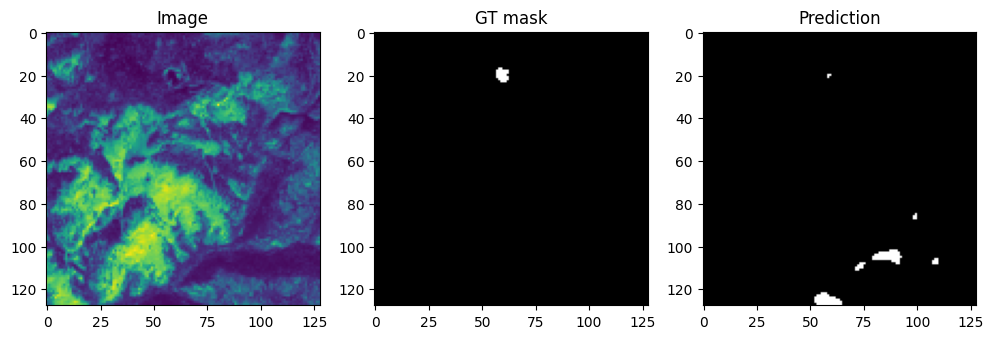

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step


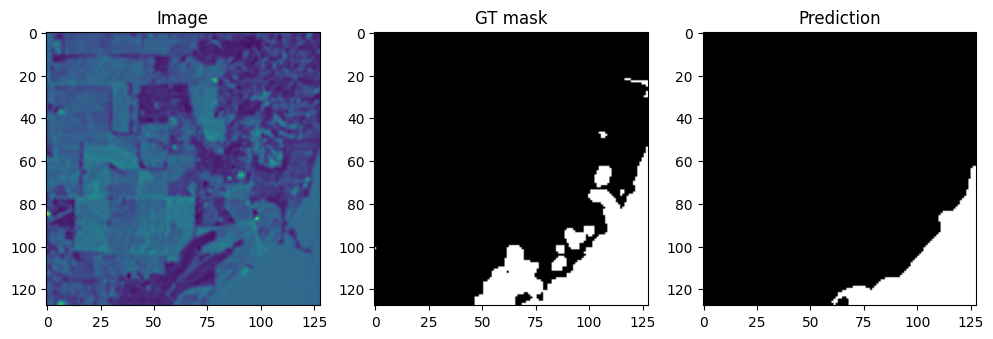

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step


c:\Users\HUAWEI\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


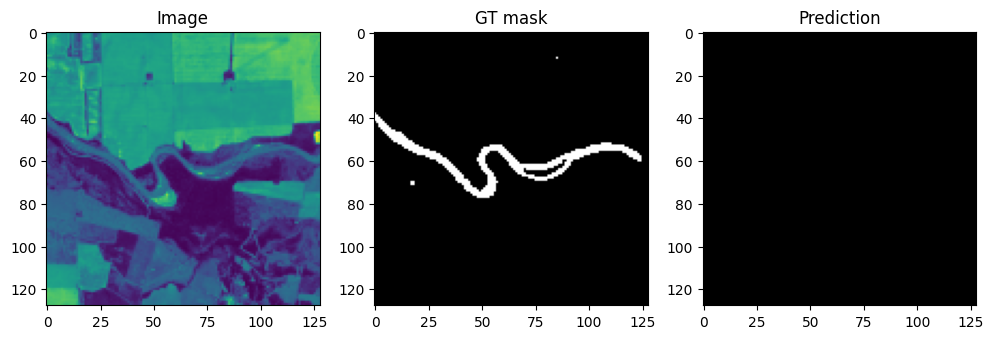

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


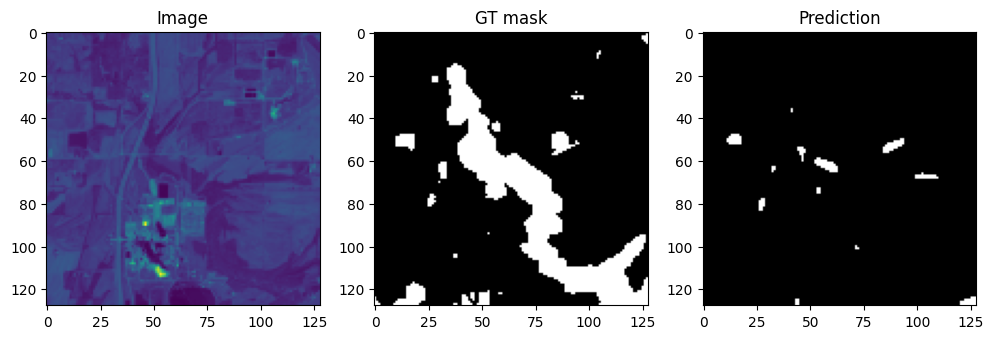

In [118]:
from sklearn.metrics import classification_report, confusion_matrix
y_true_list=[]
y_pred_list=[]
ious, precisions, recalls, f1s = [], [], [], []

for image,label in test_dataset:
    predictions=model.predict(image)

    # Binarize prediction and ground truth
    y_true = tf.cast(label[0][:,:,0], tf.uint8).numpy()
    y_pred = tf.cast(predictions[0][:,:,0] > 0.5, tf.uint8).numpy()
    y_true_list.append(y_true)
    y_pred_list.append(y_pred)
    # Compute metrics
    ious.append(iou_score(y_true, y_pred))
    precisions.append(precision_score(y_true.flatten(), y_pred.flatten(), pos_label=1))
    recalls.append(recall_score(y_true.flatten(), y_pred.flatten(), pos_label=1))
    f1s.append(f1_score(y_true.flatten(), y_pred.flatten(), pos_label=1))

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(image[0][:,:,0])

    plt.subplot(1,3,2)
    plt.title("GT mask")
    plt.imshow(label[0][:,:,0], cmap="gray")

    plt.subplot(1,3,3)
    plt.title("Prediction")
    plt.imshow((predictions[0][:,:,0] > 0.5), cmap="gray")

    plt.show()



In [117]:
print(f"Mean IoU: {np.mean(ious):.4f}")
print(f"Mean Precision: {np.mean(precisions):.4f}")
print(f"Mean Recall: {np.mean(recalls):.4f}")
print(f"Mean F1-score: {np.mean(f1s):.4f}")

Mean IoU: 0.3160
Mean Precision: 0.4491
Mean Recall: 0.2068
Mean F1-score: 0.2310


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Flatten all pixels in test set
y_true_flat = np.concatenate([y.flatten() for y in y_true_list])
y_pred_flat = np.concatenate([y.flatten() for y in y_pred_list])

print(classification_report(
    y_true_flat,
    y_pred_flat,
    labels=[0,1],
    target_names=["background", "water"]
))



              precision    recall  f1-score   support

  background       0.89      0.99      0.94    108033
       water       0.93      0.42      0.58     23039

    accuracy                           0.89    131072
   macro avg       0.91      0.71      0.76    131072
weighted avg       0.90      0.89      0.87    131072



In [123]:
# cm=confusion_matrix(y_true_flat, y_pred_flat, labels=[0,1])
# class_names=['background,water']
# plt.figure(figsize=(8,6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[class_names], yticklabels=class_names)
# plt.xlabel("Predicted Class")
# plt.ylabel("True Class")
# plt.title("Confusion Matrix")
# plt.show()